# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

* **Adding a penalty on the size of the coefficients limits the model from relying too heavily on any single feature. Without it, the model can fit the training data very closely by making coefficients large, which often leads to overfitting. The penalty pushes coefficients toward smaller values, which makes the model simpler and more stable on unseen data, even if it slightly increases training error.**

2. How does regularization provide a way of exploring the bias-variance trade-off?

* **Regularization works by adding a complexity penalty that can be dialed up or down. A stronger penalty pushes the model toward simplicity, meaning less variance, but more bias. By weakening the penalty, the model gains flexibility at the cost of greater variance. The goal is to find the sweet spot where overall error is lowest.**

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

* **Ridge regression uses a squared penalty (L2), which decreases coefficients smoothly toward zero but rarely makes them exactly zero. LASSO uses an absolute value penalty (L1), which can decrease some coefficients all the way to zero, effectively performing feature selection. As a result, LASSO tends to produce sparse models, while Ridge regression keeps all features but with lower weights.**

4. How do we typically scale variables for use in regularized regression? Why?

* **We typically standardize variables where mean=0 and variance=1 before applying regularization. This is because the penalty depends on the weight of coefficients, and if features are on different scales, the penalty would unfairly affect certain variables more than others.**

5. How is the penalty $\alpha$ typically selected?

* **The penalty α is usually chosen using cross-validation on a range of values. The value that gives the best performance on validation data is chosen as α**

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

* **No, the penalty term is not typically included when evaluating cross-validated MSE. The goal of cross validations is to measure how well the model predicts new data, so we only care about prediction error. The penalty is just a tool to help train the model, not part of the evaluation of the model.**

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 


In [167]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LassoCV, Lasso


cars = pd.read_csv("./data/cars_hw.csv")


In [168]:
cars['Age'] = 2026 - cars['Make_Year']
cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price,Age
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000,9
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000,10
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000,7
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000,9
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000,9


In [169]:
X = cars[['Mileage_Run', 'Age']]
y = cars['Price']

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?


In [170]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_scaled, y)

coef = pd.DataFrame({'Feature': poly.get_feature_names_out(['Mileage_Run', 'Age']), 'Coefficient': model.coef_})
print(coef)

interaction_coef = coef["Mileage_Run Age" == coef["Feature"]]["Coefficient"].values[0]
print("Sign of interaction between Mileage_Run and Age:", "Positive" if interaction_coef > 0 else "Negative")

             Feature   Coefficient
0        Mileage_Run  9.117748e+05
1                Age -2.481722e+05
2      Mileage_Run^2 -2.072926e+05
3    Mileage_Run Age -1.671212e+06
4              Age^2  3.505507e+05
5      Mileage_Run^3 -6.514490e+04
6  Mileage_Run^2 Age  3.388195e+05
7  Mileage_Run Age^2  7.167816e+05
8              Age^3 -2.100379e+05
Sign of interaction between Mileage_Run and Age: Negative


3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)


In [171]:
alphas = np.logspace(1, 3, 20)
model = LassoCV(alphas=alphas, cv=20, random_state=67, max_iter=100000)

model.fit(X_scaled, y)

print("Selected alpha:", model.alpha_)

Selected alpha: 88.58667904100822


4. Plot the cross-validated MSE by $\alpha$.


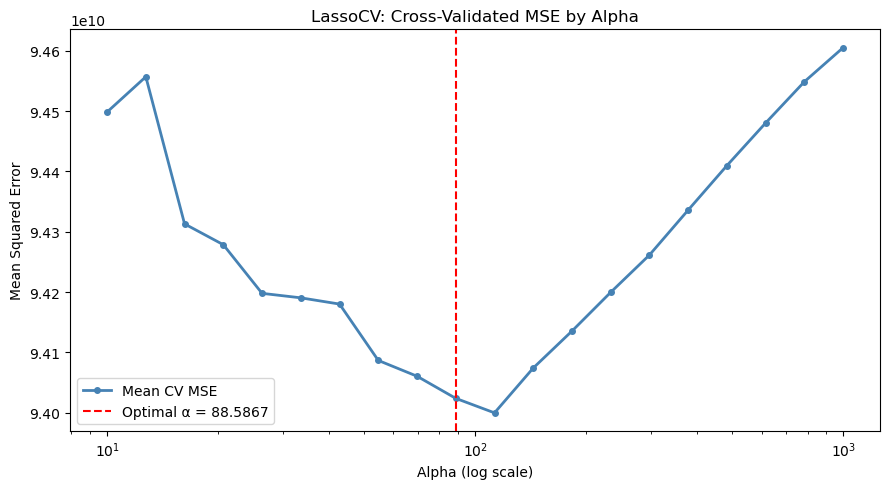

In [172]:
import matplotlib.pyplot as plt

mse_path = model.mse_path_.mean(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(alphas, mse_path, marker='o', color='steelblue', linewidth=2, markersize=4, label='Mean CV MSE')
plt.axvline(model.alpha_, color='red', linestyle='--', linewidth=1.5, label=f'Optimal α = {model.alpha_:.4f}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Mean Squared Error')
plt.title('LassoCV: Cross-Validated MSE by Alpha')
plt.legend()
plt.tight_layout()
plt.show()

5. Plot the coefficient paths by $\alpha$.


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.405e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.677e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.410e+10, toler

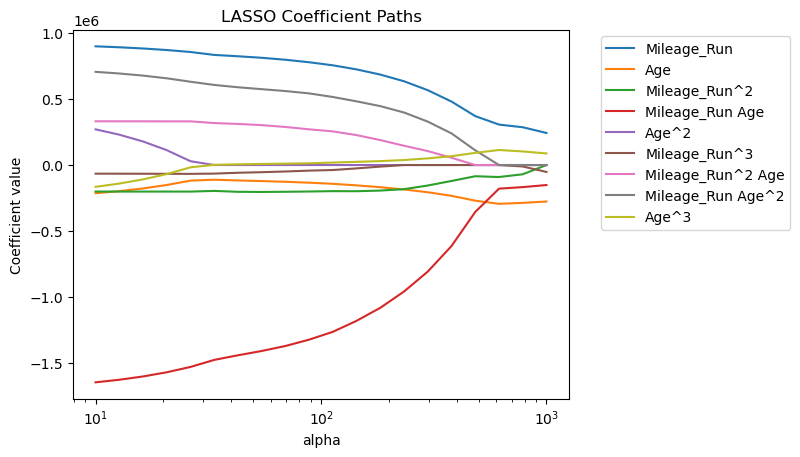

In [173]:
coef_paths = []
poly_names = poly.get_feature_names_out()

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model = model.fit(X_scaled,y)
    coef_paths.append(model.coef_)
coefs = np.array(coef_paths)
var_names = poly_names
plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=poly_names[i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

6. Which features are actually selected? What proportion are set equal to zero?


In [174]:
lasso_coef_df = pd.Series(model.coef_, index=var_names)
selected_features = lasso_coef_df[lasso_coef_df != 0]
excluded_features = lasso_coef_df[lasso_coef_df == 0]


print("Selected features:\n", selected_features.to_string())
print("\nExcluded features (set equal to 0):\n", excluded_features.to_string())

Selected features:
 Mileage_Run        242953.216388
Age               -276500.895776
Mileage_Run Age   -151598.545767
Mileage_Run^3      -52410.347536
Age^3               87796.740706

Excluded features (set equal to 0):
 Mileage_Run^2       -0.0
Age^2               -0.0
Mileage_Run^2 Age   -0.0
Mileage_Run Age^2   -0.0


7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [175]:
# used ChatGPT for assistance on clean formatting of differences beteween linear reg

comparison = pd.DataFrame({
    "linear regression": coef.set_index("Feature")["Coefficient"],
    "lasso regression": lasso_coef_df
})
comparison["magnitude"] = comparison["lasso regression"] / comparison["linear regression"]
comparison["sign_change"] = (
    (comparison["linear regression"] > 0) != (comparison["lasso regression"] > 0)
) & (comparison["lasso regression"].abs() > 1e-10)

comparison["lasso_fmt"] = ""

for idx in comparison.index:
    lin = comparison.loc[idx, "linear regression"]
    las = comparison.loc[idx, "lasso regression"]
    mag = comparison.loc[idx, "magnitude"]

    if las == 0 or abs(las) < 1e-10:
        comparison.loc[idx, "lasso_fmt"] = f"{las:>15,.2f}  [zeroed out]"
    elif mag >= 10:
        tag = f"↑{mag:.1f}x"
        comparison.loc[idx, "lasso_fmt"] = f"{las:>15,.2f}  [{tag}]"
    elif mag <= 0.1:
        tag = f"↓{1/mag:.1f}x"
        comparison.loc[idx, "lasso_fmt"] = f"{las:>15,.2f}  [{tag}]"
    else:
        tag = f"~{mag:.2f}x"
        comparison.loc[idx, "lasso_fmt"] = f"{las:>15,.2f}  [{tag}]"

    if comparison.loc[idx, "sign_change"]:
        comparison.loc[idx, "lasso_fmt"] += "   sign change"

comparison["linear regression"] = comparison["linear regression"].map(lambda x: f"{x:>15,.2f}")

print(comparison[["linear regression", "lasso_fmt"]].rename(columns={"lasso_fmt": "lasso regression"}))

                  linear regression                         lasso regression
Mileage_Run              911,774.84                     242,953.22  [~0.27x]
Age                     -248,172.19                    -276,500.90  [~1.11x]
Mileage_Run^2           -207,292.63                      -0.00  [zeroed out]
Mileage_Run Age       -1,671,212.36                    -151,598.55  [↓11.0x]
Age^2                    350,550.72                      -0.00  [zeroed out]
Mileage_Run^3            -65,144.90                     -52,410.35  [~0.80x]
Mileage_Run^2 Age        338,819.46                      -0.00  [zeroed out]
Mileage_Run Age^2        716,781.58                      -0.00  [zeroed out]
Age^3                   -210,037.89        87,796.74  [↓-2.4x]   sign change


The only coefficient that underwent an increase in magnitude from the linear regression to the LASSO was Age having increased by 1.11x. The only coefficient that underwent a sign change was Age^3 having gone from a linear regression coefficient of -210,037.89 to a LASSO coefficient of 87,796.74. My interpretation of this sign change is that Age^3 is a relatively unstable variable, so it was shrunken and changed signs by the LASSO.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.


In [176]:
heart = pd.read_csv("./data/heart_failure_clinical_records_dataset.csv")

X1 = heart[['age', 'ejection_fraction', 'serum_creatinine']]
X2 = heart[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]
y = heart['DEATH_EVENT']

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X1)
poly_names = poly.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

poly2 = PolynomialFeatures(interaction_only=True, include_bias=False)
X_poly2 = poly2.fit_transform(X2)
poly_names2 = poly2.get_feature_names_out(['anaemia', 'diabetes', 'high_blood_pressure', 'smoking'])

X_full = np.concatenate([X_scaled, X_poly2], axis=1)
X_names = np.concatenate([poly_names, poly_names2])

print(f"Feature matrix shape: {X_full.shape}")

Feature matrix shape: (299, 29)


2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?


In [177]:
lr = LinearRegression()
lr.fit(X_full, y)
coef = pd.DataFrame({'Feature': X_names, 'Coefficient': lr.coef_})
print(coef)

                                   Feature  Coefficient
0                                      age     1.539156
1                        ejection_fraction    -2.192494
2                         serum_creatinine    -0.853588
3                                    age^2    -3.678654
4                    age ejection_fraction    -0.600918
5                     age serum_creatinine     1.841563
6                      ejection_fraction^2     3.430976
7       ejection_fraction serum_creatinine     2.673394
8                       serum_creatinine^2    -2.647041
9                                    age^3     1.993135
10                 age^2 ejection_fraction     0.908026
11                  age^2 serum_creatinine    -0.697522
12                 age ejection_fraction^2    -0.081206
13  age ejection_fraction serum_creatinine    -1.577665
14                  age serum_creatinine^2     1.284099
15                     ejection_fraction^3    -1.250341
16    ejection_fraction^2 serum_creatinine    -1

What stood out most to me is that diabetes, high_blood_pressure, and smoking were negatively correlated with death. Additionally, serum creatinine being negatively correlated with death is noteworhty. In general, higher creatinine levels indicates that the kidneys aren't properly filtering out waste, which increases the risk of death, according to the Mayo Clinic. It seems to me that these anomalies can be explained by a model that is overfitting given the small observation size of 299. 

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)


In [178]:
alphas = np.logspace(-5,5,30)

model = LassoCV(alphas=alphas, cv=20, random_state=67, max_iter=100000)
model.fit(X_full, y)
print("Selected alpha:", model.alpha_)

Selected alpha: 0.005736152510448681


4. Plot the cross-validated MSE by $\alpha$.


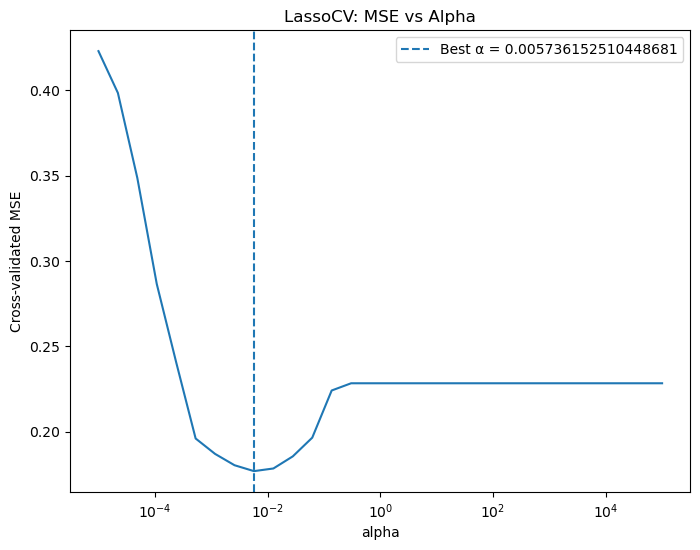

In [179]:
mean_mse = np.mean(model.mse_path_, axis=1)

plt.figure(figsize=(8,6))
plt.semilogx(model.alphas_, mean_mse)
plt.axvline(model.alpha_, linestyle='--', label=f'Best α = {model.alpha_}')
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("LassoCV: MSE vs Alpha")
plt.legend()
plt.show()

5. Plot the coefficient paths by $\alpha$.


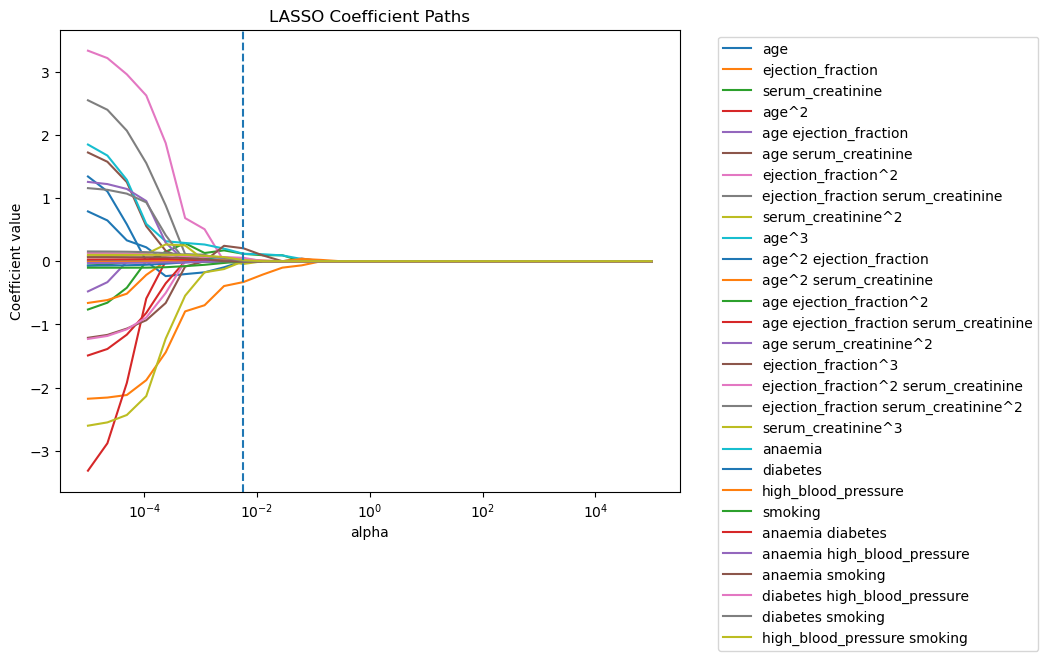

In [180]:
coef_paths = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=100000)
    lasso.fit(X_full, y)
    coef_paths.append(lasso.coef_)

coefs = np.array(coef_paths)

plt.figure(figsize=(8,6))

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.axvline(model.alpha_, linestyle='--')

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.legend(X_names, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [181]:
var_names = list(poly.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine'])) + list(poly2.get_feature_names_out(['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']))
lasso_coef_df = pd.Series(model.coef_, index=var_names)
selected_features = lasso_coef_df[lasso_coef_df != 0]
excluded_features = lasso_coef_df[lasso_coef_df == 0]    

print("Selected features ({}):\n".format(len(selected_features)), selected_features.to_string())
print("\nExcluded features ({}):\n".format(len(excluded_features)), excluded_features.to_string())

Selected features (12):
 ejection_fraction                      -0.329656
serum_creatinine                        0.116875
age^3                                   0.117992
ejection_fraction^3                     0.204822
ejection_fraction^2 serum_creatinine    0.032801
serum_creatinine^3                     -0.043266
anaemia                                 0.014178
diabetes                                0.000607
high_blood_pressure                     0.013608
diabetes high_blood_pressure            0.053968
diabetes smoking                        0.003466
high_blood_pressure smoking             0.017805

Excluded features (17):
 age                                      -0.0
age^2                                     0.0
age ejection_fraction                    -0.0
age serum_creatinine                      0.0
ejection_fraction^2                       0.0
ejection_fraction serum_creatinine        0.0
serum_creatinine^2                       -0.0
age^2 ejection_fraction                

In [182]:

comparison = pd.DataFrame({
    "linear regression": coef.set_index("Feature")["Coefficient"],
    "lasso regression": lasso_coef_df
})
comparison["magnitude"] = comparison["lasso regression"] / comparison["linear regression"]
comparison["sign_change"] = (
    (comparison["linear regression"] > 0) != (comparison["lasso regression"] > 0)
) & (comparison["lasso regression"].abs() > 1e-10)

comparison["lasso_fmt"] = ""

for idx in comparison.index:
    lin = comparison.loc[idx, "linear regression"]
    las = comparison.loc[idx, "lasso regression"]
    mag = comparison.loc[idx, "magnitude"]

    if las == 0 or abs(las) < 1e-10:
        comparison.loc[idx, "lasso_fmt"] = f"{las:>15,.2f}  [zeroed out]"
    elif mag >= 10:
        tag = f"↑{mag:.1f}x"
        comparison.loc[idx, "lasso_fmt"] = f"{las:>15,.2f}  [{tag}]"
    elif mag <= 0.1:
        tag = f"↓{1/mag:.1f}x"
        comparison.loc[idx, "lasso_fmt"] = f"{las:>15,.2f}  [{tag}]"
    else:
        tag = f"~{mag:.2f}x"
        comparison.loc[idx, "lasso_fmt"] = f"{las:>15,.2f}  [{tag}]"

    if comparison.loc[idx, "sign_change"]:
        comparison.loc[idx, "lasso_fmt"] += "   sign change"

comparison["linear regression"] = comparison["linear regression"].map(lambda x: f"{x:>15,.2f}")

print(comparison[["linear regression", "lasso_fmt"]].rename(columns={"lasso_fmt": "lasso regression"}))

                                       linear regression  \
age                                                 1.54   
ejection_fraction                                  -2.19   
serum_creatinine                                   -0.85   
age^2                                              -3.68   
age ejection_fraction                              -0.60   
age serum_creatinine                                1.84   
ejection_fraction^2                                 3.43   
ejection_fraction serum_creatinine                  2.67   
serum_creatinine^2                                 -2.65   
age^3                                               1.99   
age^2 ejection_fraction                             0.91   
age^2 serum_creatinine                             -0.70   
age ejection_fraction^2                            -0.08   
age ejection_fraction serum_creatinine             -1.58   
age serum_creatinine^2                              1.28   
ejection_fraction^3                     

6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.


17 out of 29 features are set equal to zero. The only coefficient that increased in magnitude form linear regression to LASSO was anaemia. 5 variables underwent a sign change: serum_creatinine, ejection_fraction^3, ejection_fraction^2 serum_creatinine, diabetes, high_blood_pressure. The LASSO seems ot make more sense. Some of the variables mentioned before like diabetes and high_blood_pressure are expectedly positive indicators of risk of death. From the perspective of the bias–variance trade-off, the linear regression model has low bias but high variance because it overfits the training data, especially with many polynomial and interaction terms. This high variance leads to unstable coefficient estimates and unintuitive sign patterns. LASSO, on the other hand, moves along the trade-off by introducing bias through the L1 penalty, shrinking many coefficients toward zero and eliminating others entirely. While this increases bias slightly, it substantially reduces variance.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
* **The objective function for this problem is $$ \frac{1}{n} \sum_{i=1}^{n}\left(\tilde{y}_i - b_0 - b_1 \tilde{x}_i \right)^2+ \alpha b_1^2$$**
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.

#### Derivative with respect to \( $b_0$ \):

$$
\frac{\partial J}{\partial b_0}
=
-\frac{2}{n}
\sum_{i=1}^{n}
\left(\tilde{y}_i - b_0 - b_1 \tilde{x}_i \right).
$$

Set equal to zero:
$$
\sum_{i=1}^{n}
\left(\tilde{y}_i - b_0 - b_1 \tilde{x}_i \right) = 0.
$$

Because the variables are mean-centered,
$$
\sum \tilde{y}_i = 0,
\qquad
\sum \tilde{x}_i = 0.
$$

This simplifies to:
$$
- n b_0 = 0
\quad \Rightarrow \quad
b_0 = 0.
$$

#### Derivative with respect to \( $b_1$ \):
$$
\frac{\partial J}{\partial b_1}
=
-\frac{2}{n}
\sum_{i=1}^{n}
\tilde{x}_i
\left(\tilde{y}_i - b_1 \tilde{x}_i \right)
+ 2 \alpha b_1 = 0
$$

$$
\frac{1}{n}
\sum \tilde{x}_i \tilde{y}_i
=
b_1
\left(
\frac{1}{n}
\sum \tilde{x}_i^2
+
\alpha
\right).
$$

$$
b_1
=
\frac{\frac{1}{n} \sum \tilde{x}_i \tilde{y}_i}
{\frac{1}{n} \sum \tilde{x}_i^2 + \alpha}
$$

3. How does increasing $\alpha$ change the slope coefficient?
* **Looking at our dervied equation for $b_1$, increasing $\alpha$ causes the numerator to increase leading to the whole of $b_1$ to approach 0.**

4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

* **The core challenge with LASSO is that |b₁| has a sharp corner at zero, making it non-differentiable there, so you can't simply take a derivative and set it to zero.**